# Redes neuronales convolucionales: de MNIST a imágenes reales

En este cuaderno vas a trabajar con redes neuronales convolucionales, conocidas como CNNs. Primero usamos MNIST porque es un dataset pequeño y controlado. Luego pasamos a `cats_vs_dogs`, que tiene imágenes reales y por eso introduce desafíos más cercanos a una aplicación práctica.

## Objetivos de aprendizaje

Al finalizar este cuaderno, vas a poder:

- explicar qué aporta una capa convolucional;
- entrenar una CNN para clasificar dígitos escritos a mano;
- evaluar el modelo con datos de prueba;
- comparar imágenes controladas con imágenes reales;
- identificar riesgos de sobreajuste y sesgos en datasets visuales.

## Microglosario

- **Píxel**: unidad mínima de una imagen digital.
- **Canal**: componente de color de una imagen. Una imagen en escala de grises tiene 1 canal; una imagen RGB tiene 3.
- **Filtro**: conjunto de valores que recorre la imagen para detectar patrones locales.
- **Convolución**: operación que aplica filtros sobre la imagen.
- **Pooling**: reducción del tamaño espacial de una representación.
- **Flatten**: transformación de una matriz en un vector.
- **Softmax**: salida probabilística para varias clases.
- **Sigmoid**: salida probabilística para clasificación binaria.

# Parte A. CNN con MNIST

MNIST contiene imágenes de dígitos escritos a mano del 0 al 9. Es un buen primer caso porque las imágenes son pequeñas, están centradas y tienen poca variabilidad de fondo.

## 1. Importar herramientas

In [1]:
# Este bloque importa las bibliotecas que se usaran mas adelante
# necesarias para cálculo numérico, visualización y entrenamiento de redes neuronales convolucionales

import math                        # Operaciones matemáticas básicas (ej: ceil, floor, pi)
import matplotlib.pyplot as plt    # Visualización de imágenes y gráficos de métricas
import numpy as np                 # Manipulación de arrays y operaciones numéricas
import tensorflow as tf            # Framework principal para construir y entrenar la CNN
import tensorflow_datasets as tfds # Carga de datasets estándar listos para usar con TensorFlow


## 2. Cargar el dataset MNIST

In [2]:
# Este bloque separa datos de entrenamiento, validacion o prueba; 
# evaluar con datos no usados para ajustar pesos permite estimar si el modelo generaliza o si solo memorizó los ejemplos.
# Carga del dataset MNIST y extracción de metadatos relevantes para el entrenamiento

datos_mnist, metadatos_mnist = tfds.load(
    "mnist",          # Nombre del dataset a descargar desde TensorFlow Datasets
    as_supervised=True, # Devuelve tuplas (imagen, etiqueta) en lugar de diccionarios
    with_info=True,   # Incluye metadatos: clases, cantidad de ejemplos, descripción, etc.
)

nombres_clases_mnist = metadatos_mnist.features["label"].names          # Lista de nombres de las 10 clases (dígitos del 0 al 9)
cantidad_mnist_entrenamiento = metadatos_mnist.splits["train"].num_examples  # Total de imágenes en el conjunto de entrenamiento (60.000)
cantidad_mnist_prueba = metadatos_mnist.splits["test"].num_examples          # Total de imágenes en el conjunto de prueba (10.000)

print("Imágenes de entrenamiento:", cantidad_mnist_entrenamiento)
print("Imágenes de prueba:", cantidad_mnist_prueba)
print("Clases:", nombres_clases_mnist)


Imágenes de entrenamiento: 60000
Imágenes de prueba: 10000
Clases: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


**Consigna de lectura:** observá la cantidad de ejemplos. ¿Por qué ayuda tener muchas imágenes para entrenar un modelo?

**Respuesta:** Ayuda porque la red ve mas variaciones de una misma clase. En imagenes, una misma categoria puede cambiar por tamano, rotacion, iluminacion, fondo o estilo; cuantos mas ejemplos diversos haya, menos probable es que el modelo aprenda un detalle accidental.

## 3. Separar y normalizar datos

Normalizamos los píxeles para que sus valores queden entre 0 y 1. Esto suele facilitar el entrenamiento.

In [3]:
# Este bloque separa datos de entrenamiento, validacion o prueba
# Normalización del dataset MNIST: conversión a float32 y escalado de píxeles al rango [0, 1]

def normalizar_mnist(imagen, etiqueta):
    imagen = tf.cast(imagen, tf.float32)  # Convierte los píxeles de uint8 a float32 para operar con decimales
    imagen = imagen / 255.0               # Escala los valores de [0, 255] a [0.0, 1.0]
    return imagen, etiqueta               # Devuelve la imagen normalizada junto con su etiqueta sin modificar


datos_mnist_entrenamiento = datos_mnist["train"]  # Separa el subconjunto de entrenamiento del dataset cargado
datos_mnist_prueba = datos_mnist["test"]           # Separa el subconjunto de prueba del dataset cargado

datos_mnist_entrenamiento = datos_mnist_entrenamiento.map(normalizar_mnist)  # Aplica la normalización a cada imagen de entrenamiento
datos_mnist_prueba = datos_mnist_prueba.map(normalizar_mnist)                # Aplica la normalización a cada imagen de prueba

datos_mnist_entrenamiento = datos_mnist_entrenamiento.cache()  # Almacena el dataset en memoria para acelerar las épocas siguientes
datos_mnist_prueba = datos_mnist_prueba.cache()                # Ídem para el conjunto de prueba

print("MNIST normalizado.")


MNIST normalizado.


## 4. Visualizar ejemplos

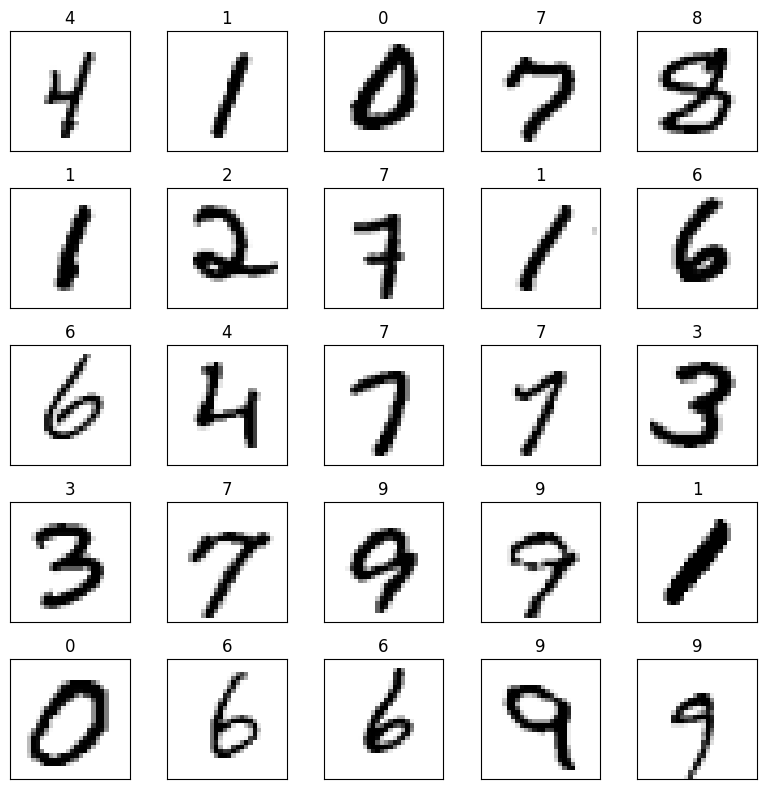

In [4]:
# Este bloque visualiza datos, resultados o curvas de aprendizaje; las imagenes y graficos facilitan detectar patrones, 
# errores, sesgos y cambios en el entrenamiento.
# Visualización de las primeras 25 imágenes del conjunto de entrenamiento en una grilla de 5x5

plt.figure(figsize=(8, 8))  # Crea una figura de 8x8 pulgadas

for indice, (imagen, etiqueta) in enumerate(datos_mnist_entrenamiento.take(25)):  # Itera sobre las primeras 25 imágenes
    plt.subplot(5, 5, indice + 1)                          # Ubica cada imagen en su celda dentro de la grilla 5x5
    plt.imshow(imagen[:, :, 0], cmap=plt.cm.binary)        # Muestra el canal de grises (índice 0) con colormap binario
    plt.xticks([])                                         # Oculta las marcas del eje X
    plt.yticks([])                                         # Oculta las marcas del eje Y
    plt.title(nombres_clases_mnist[etiqueta.numpy()])      # Muestra el nombre de la clase como título de cada imagen

plt.tight_layout()  # Ajusta el espaciado entre subgráficos para evitar superposiciones
plt.show()          # Renderiza y muestra la figura completa


### Resumen 

**Que se hizo:** se visualiza datos, resultados o curvas de aprendizaje.

**Por que se hizo:** las imagenes y graficos facilitan detectar patrones, errores, sesgos y cambios en el entrenamiento.

**Consigna de lectura:** mirá la variedad de escrituras. ¿Qué dígitos parecen más fáciles o más difíciles de distinguir?

- 1 - 9 - 0 -6


## 5. Construir una CNN

Una CNN conserva la estructura espacial de la imagen durante las primeras capas. Esto permite detectar bordes, curvas y combinaciones de patrones locales antes de clasificar.

### ¿Qué es una CNN?

Una **CNN** es una **red neuronal convolucional**. Su nombre viene de *Convolutional Neural Network*.

Es un tipo de red neuronal especialmente útil para trabajar con **imágenes**, porque no analiza los píxeles como una simple lista, sino como una estructura espacial: alto, ancho y canales de color.

En una imagen importa mucho dónde está cada píxel y qué píxeles tiene cerca. Una CNN aprovecha esa información para aprender patrones visuales.

Por ejemplo, una CNN puede aprender primero rasgos simples:

- bordes
- curvas
- líneas verticales
- líneas horizontales
- esquinas

Luego combina esos rasgos para reconocer formas más complejas:

- un círculo
- la curva de un número
- una silueta
- una textura
- una parte de un objeto

Una CNN suele tener capas como:

- **Conv2D:** busca patrones pequeños en la imagen usando filtros.
- **MaxPooling2D:** reduce el tamaño de la imagen conservando la información más importante.
- **Flatten:** convierte los mapas de características en una lista de valores.
- **Dense:** toma la decisión final, por ejemplo “esto parece un 5”.

Dicho de forma simple:

```text
Imagen → detectar bordes → detectar formas → combinar rasgos → predecir clase

## ¿Qué es MNIST?

**MNIST** es un conjunto de datos muy usado para aprender redes neuronales aplicadas a imágenes.

Contiene imágenes pequeñas de **dígitos escritos a mano**, del `0` al `9`.

Cada imagen tiene:

- tamaño de **28 x 28 píxeles**
- escala de grises
- una etiqueta asociada, por ejemplo `0`, `1`, `2`, ..., `9`

Esto significa que cada imagen representa un número manuscrito y el modelo debe aprender a reconocer cuál es.

Por ejemplo:

```text
Imagen de un 3 → etiqueta correcta: 3
Imagen de un 8 → etiqueta correcta: 8
Imagen de un 1 → etiqueta correcta: 1

In [5]:
# Este bloque define o carga un modelo de aprendizaje automatico; la arquitectura establece que 
# patrones puede aprender: relaciones simples, formas, bordes, texturas, objetos o conceptos 
# visuales mas complejos.
# Definición, compilación y resumen de la arquitectura CNN para clasificación de dígitos MNIST

modelo_mnist = tf.keras.Sequential([
    tf.keras.layers.Conv2D(
        filters=32,              # 32 filtros para detectar características básicas (bordes, curvas)
        kernel_size=(3, 3),      # Ventana de convolución de 3x3 píxeles
        activation="relu",       # ReLU elimina valores negativos e introduce no linealidad
        input_shape=(28, 28, 1), # Forma de entrada: imágenes de 28x28 píxeles en escala de grises
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),                              # Reduce el mapa de características a la mitad, conservando los valores máximos
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),   # Segunda capa convolucional con 64 filtros para patrones más complejos
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),                              # Segunda reducción espacial por max pooling
    tf.keras.layers.Flatten(),                                                   # Aplana el tensor 2D a un vector 1D para conectar con las capas densas
    tf.keras.layers.Dense(units=100, activation="relu"),                         # Capa densa intermedia con 100 neuronas para combinar características extraídas
    tf.keras.layers.Dense(units=10, activation="softmax"),                       # Capa de salida con 10 neuronas (una por clase); softmax da probabilidades que suman 1
])

modelo_mnist.compile(
    optimizer="adam",                        # Optimizador Adam: adaptativo y eficiente para redes profundas
    loss="sparse_categorical_crossentropy",  # Función de pérdida para clasificación multiclase con etiquetas enteras
    metrics=["accuracy"],                    # Métrica de seguimiento: porcentaje de predicciones correctas
)

modelo_mnist.summary()  # Imprime la arquitectura completa con cantidad de parámetros por capa


c:\Proyectos\rodriguez-carmen-pdi-1c-2026\venv_tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       160,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,926 (702.84 KB)

 Trainable params: 179,926 (702.84 KB)

 Non-trainable params: 0 (0.00 B)

### Resumen 

**Que se hizo:** se define o carga un modelo de aprendizaje automatico.

**Por que se hizo:** la arquitectura establece que patrones puede aprender: relaciones simples, formas, bordes, texturas, objetos o conceptos visuales mas complejos.

**Consigna de lectura:** identificá dónde aparecen las capas convolucionales, las capas de pooling y las capas densas.

**Respuesta orientativa:** Las capas `Conv2D` aparecen al comienzo y extraen rasgos locales como bordes o curvas. Las capas de `MaxPooling` reducen el tamano espacial conservando senales importantes. Las capas `Dense` aparecen al final y usan esos rasgos para decidir la clase.

### Tipos de capas en una CNN

Una **CNN** o red neuronal convolucional utiliza distintos tipos de capas para analizar imágenes. Cada tipo de capa cumple una función específica dentro del modelo.

#### Capas convolucionales

Las **capas convolucionales** son las encargadas de detectar patrones visuales en la imagen.

Usan filtros pequeños, llamados **kernels**, que recorren la imagen buscando rasgos como:

- bordes
- líneas
- curvas
- esquinas
- texturas
- formas simples

Estas capas conservan la estructura espacial de la imagen, es decir, tienen en cuenta qué píxeles están cerca de otros.


Función principal: detectar características visuales.


#### Capas de pooling

Las **capas de pooling** reducen el tamaño de la información generada por las capas convolucionales.

La más común es `MaxPooling2D`, que toma una pequeña región y conserva el valor más alto.

Sirven para:

- disminuir la cantidad de datos
- hacer el modelo más liviano
- conservar las señales más importantes
- reducir el efecto de pequeños desplazamientos en la imagen


Función principal: resumir la información visual conservando lo más relevante.


#### Capas densas

Las **capas densas** aparecen normalmente al final de la red.

Después de que las capas convolucionales y de pooling extraen características de la imagen, las capas densas usan esa información para tomar la decisión final.

Por ejemplo, si el modelo clasifica dígitos del `0` al `9`, la última capa puede tener 10 neuronas, una por cada clase.

Función principal: interpretar las características extraídas y producir la predicción final.


### Flujo general de una CNN

Imagen
→ capas convolucionales
→ capas de pooling
→ capas densas
→ predicción final


### Idea clave

Las capas convolucionales detectan rasgos visuales, las capas de pooling resumen esos rasgos y las capas densas deciden a qué clase pertenece la imagen.

## 6. Preparar lotes y entrenar

In [6]:
# Este bloque separa datos de entrenamiento, validacion o prueba
# Preparación de los datos en lotes y entrenamiento del modelo CNN sobre MNIST

TAMANO_LOTE = 32   # Cantidad de imágenes procesadas por iteración de gradiente
EPOCAS_MNIST = 5   # Número de pasadas completas sobre el dataset de entrenamiento

lotes_mnist_entrenamiento = datos_mnist_entrenamiento.shuffle(cantidad_mnist_entrenamiento)  # Mezcla aleatoria para evitar que el orden de los datos sesgue el aprendizaje
lotes_mnist_entrenamiento = lotes_mnist_entrenamiento.batch(TAMANO_LOTE)                    # Agrupa las imágenes en lotes de 32
lotes_mnist_entrenamiento = lotes_mnist_entrenamiento.prefetch(tf.data.AUTOTUNE)            # Precarga el siguiente lote mientras el modelo entrena el actual

lotes_mnist_prueba = datos_mnist_prueba.batch(TAMANO_LOTE)          # Agrupa las imágenes de prueba en lotes (sin mezclar, el orden no importa en evaluación)
lotes_mnist_prueba = lotes_mnist_prueba.prefetch(tf.data.AUTOTUNE)  # Precarga lotes de prueba para acelerar la evaluación

historial_mnist = modelo_mnist.fit(
    lotes_mnist_entrenamiento,       # Dataset de entrenamiento en lotes
    epochs=EPOCAS_MNIST,             # Entrena durante 5 épocas
    validation_data=lotes_mnist_prueba,  # Evalúa en el conjunto de prueba al final de cada época
)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9594 - loss: 0.1325 - val_accuracy: 0.9780 - val_loss: 0.0645
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9860 - loss: 0.0441 - val_accuracy: 0.9881 - val_loss: 0.0371
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9904 - loss: 0.0300 - val_accuracy: 0.9896 - val_loss: 0.0315
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9926 - loss: 0.0228 - val_accuracy: 0.9909 - val_loss: 0.0279
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9941 - loss: 0.0175 - val_accuracy: 0.9866 - val_loss: 0.0411


## 7. Evaluar MNIST

In [ ]:
# Este bloque evalua el rendimiento del modelo; las métricas permiten distinguir 
# entre una impresion visual y una medición concreta de aciertos, errores y confusiones.
# Evaluación final del modelo sobre el conjunto de prueba y reporte de métricas

perdida_mnist, precision_mnist = modelo_mnist.evaluate(lotes_mnist_prueba)  # Calcula la pérdida y precisión sobre datos no vistos durante el entrenamiento

print(f"Pérdida en prueba: {perdida_mnist:.4f}")           # Valor de la función de pérdida (cuanto menor, mejor)
print(f"Precisión en prueba: {precision_mnist:.4f}")       # Proporción de aciertos en formato decimal (ej: 0.9921)
print(f"Precisión equivalente: {precision_mnist * 100:.2f}%")  # Misma precisión expresada en porcentaje (ej: 99.21%)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9866 - loss: 0.0411
Pérdida en prueba: 0.0411
Precisión en prueba: 0.9866
Precisión equivalente: 98.66%


### Resumen

**Que se hizo:** se evalua el rendimiento del modelo.

**Por que se hizo:** las métricas permiten distinguir entre una impresion visual y una medición concreta de aciertos, errores y confusiones.

**Consigna de lectura:** compará este resultado con una red densa simple. ¿Qué ventaja esperás de una CNN en imágenes

La ventaja de una CNN es que conserva la estructura espacial de la imagen. Mientras una red densa trata los pixeles como una lista, la CNN aprende patrones locales: bordes, esquinas, texturas y combinaciones de formas.

## 8. Visualizar predicciones de MNIST

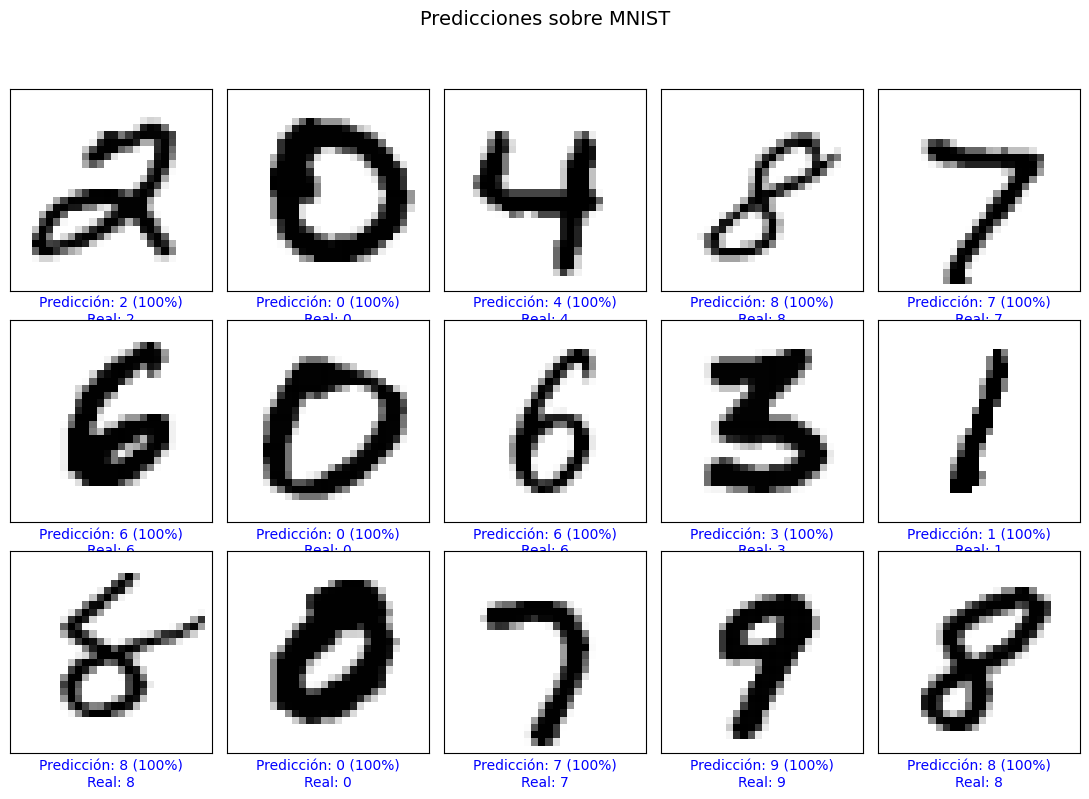

In [ ]:
# Este bloque genera predicciones a partir del modelo
# Predicción sobre un lote de prueba y visualización de resultados con indicación de aciertos y errores

for imagenes_prueba, etiquetas_prueba in lotes_mnist_prueba.take(1):  # Toma un único lote del conjunto de prueba
    imagenes_prueba = imagenes_prueba.numpy()                          # Convierte el tensor de imágenes a array NumPy
    etiquetas_prueba = etiquetas_prueba.numpy()                        # Convierte el tensor de etiquetas a array NumPy
    probabilidades_mnist = modelo_mnist.predict(imagenes_prueba, verbose=0)  # Genera predicciones para todas las imágenes del lote
    break  # Sale tras el primer lote; solo se necesitan 32 imágenes para la visualización


def graficar_imagen_mnist(indice, probabilidades, etiquetas_reales, imagenes):
    probabilidades_imagen = probabilidades[indice]   # Vector de 10 probabilidades (una por clase) para la imagen indicada
    etiqueta_real = etiquetas_reales[indice]         # Clase verdadera de la imagen
    imagen = imagenes[indice]                        # Array de píxeles de la imagen

    etiqueta_predicha = np.argmax(probabilidades_imagen)  # Clase con mayor probabilidad = predicción del modelo
    confianza = np.max(probabilidades_imagen)             # Probabilidad máxima = nivel de confianza de la predicción

    if etiqueta_predicha == etiqueta_real:  # Predicción correcta: se colorea en azul
        color = "blue"
    else:                                   # Predicción incorrecta: se colorea en rojo
        color = "red"

    plt.grid(False)   # Oculta la grilla de fondo
    plt.xticks([])    # Oculta marcas del eje X
    plt.yticks([])    # Oculta marcas del eje Y
    plt.imshow(imagen[:, :, 0], cmap=plt.cm.binary)  # Muestra la imagen en escala de grises
    plt.xlabel(
        f"Predicción: {nombres_clases_mnist[etiqueta_predicha]} ({confianza * 100:.0f}%)\n"  # Clase predicha y confianza
        f"Real: {nombres_clases_mnist[etiqueta_real]}",  # Clase verdadera para comparar visualmente
        color=color,  # Azul si acertó, rojo si falló
    )


filas = 3     # Filas de la grilla de visualización
columnas = 5  # Columnas de la grilla de visualización
cantidad_imagenes = filas * columnas  # Total de imágenes a mostrar: 15

plt.figure(figsize=(2 * columnas + 1, 2 * filas + 2))  # Tamaño de figura proporcional a la grilla
plt.suptitle("Predicciones sobre MNIST", fontsize=14)  # Título general de la figura

for indice in range(cantidad_imagenes):                          # Itera sobre las 15 imágenes a graficar
    plt.subplot(filas, columnas, indice + 1)                     # Selecciona la celda correspondiente en la grilla
    graficar_imagen_mnist(indice, probabilidades_mnist, etiquetas_prueba, imagenes_prueba)  # Dibuja imagen con predicción

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Ajusta márgenes reservando espacio para el título superior
plt.show()                               # Renderiza y muestra la figura completa


**Consigna de lectura:** elegí una predicción incorrecta, si aparece. ¿El error resulta comprensible visualmente?

No hay predicciones incorrectas, pero hay un número 8 con la parte de arriba abierta, si esa imagen estuviera mezclada con datos de tipo letras, la verdad es que yo habría jurado que era una letra s



# Parte B. CNN con imágenes reales: gatos y perros

Ahora pasamos a un caso menos controlado. Las imágenes de gatos y perros tienen fondos, tamaños, posturas e iluminaciones muy variadas. Esto acerca el problema a la creación de datasets propios.

## 9. Cargar `cats_vs_dogs`

Este dataset puede tardar en descargarse la primera vez. Si la conexión es inestable, conviene ejecutar esta parte con anticipación.

In [9]:
# Carga de gatos y perros desde CIFAR-10 y filtrado de las clases relevantes
# CIFAR-10 está disponible directamente en Keras, no requiere descarga externa y no contiene archivos corruptos

nombres_clases_animales = ["cat", "dog"]  # Clases de interés: gato (clase 3) y perro (clase 5) dentro de CIFAR-10

(x_entrenamiento, y_entrenamiento), (x_prueba, y_prueba) = tf.keras.datasets.cifar10.load_data()  # Descarga CIFAR-10: 50.000 imágenes de entrenamiento y 10.000 de prueba en 10 clases

mascara_entrenamiento = (y_entrenamiento[:, 0] == 3) | (y_entrenamiento[:, 0] == 5)  # Máscara booleana para seleccionar gatos (3) y perros (5) del conjunto de entrenamiento
mascara_prueba = (y_prueba[:, 0] == 3) | (y_prueba[:, 0] == 5)                      # Ídem para el conjunto de prueba

x_animales_entrenamiento = x_entrenamiento[mascara_entrenamiento]                                 # Imágenes RGB de gatos y perros del conjunto de entrenamiento
y_animales_entrenamiento = (y_entrenamiento[mascara_entrenamiento][:, 0] == 5).astype("float32") # Etiquetas binarias: 0=gato, 1=perro

x_animales_prueba = x_prueba[mascara_prueba]                                                     # Imágenes RGB de gatos y perros del conjunto de prueba
y_animales_prueba = (y_prueba[mascara_prueba][:, 0] == 5).astype("float32")                      # Etiquetas binarias para el conjunto de prueba

x_animales_entrenamiento = x_animales_entrenamiento / 255.0  # Normaliza píxeles de entrenamiento al rango [0, 1]
x_animales_prueba = x_animales_prueba / 255.0                # Normaliza píxeles de prueba al rango [0, 1]

cantidad_animales = len(x_animales_entrenamiento)  # Total de imágenes de entrenamiento disponibles
print("Imágenes de entrenamiento:", cantidad_animales)
print("Imágenes de prueba:", len(x_animales_prueba))
print("Clases:", nombres_clases_animales)

Imágenes de entrenamiento: 10000
Imágenes de prueba: 2000
Clases: ['cat', 'dog']


### Resumen

**Que se hizo:** se cargó el dataset CIFAR-10 y se filtraron las clases gato y perro para construir un problema de clasificación binaria.

**Por que se hizo:** CIFAR-10 está disponible directamente en Keras sin necesidad de descarga externa ni manejo de archivos corruptos, lo que lo hace una alternativa robusta para trabajar con imágenes reales de animales.

**Consigna de lectura:** pensá qué diferencias hay entre clasificar dígitos centrados y clasificar fotos reales tomadas en contextos variados.

**Respuesta orientativa:** Clasificar digitos centrados es un problema controlado: fondo simple, objeto alineado y clases claras. Las fotos reales agregan fondos, sombras, encuadres, oclusiones y cambios de escala; por eso exigen mas datos, preprocesamiento y modelos mas robustos.

## 10. Visualizar imágenes reales

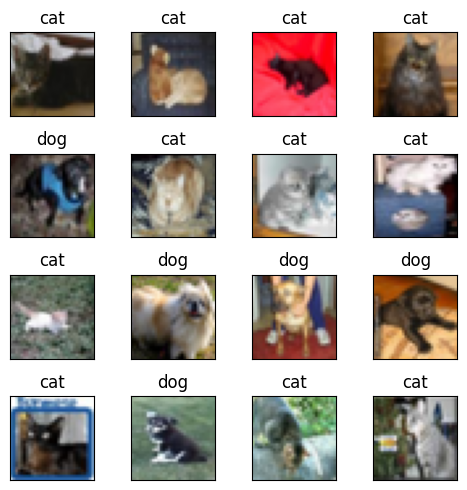

In [17]:
# Visualización de las primeras 16 imágenes del dataset de gatos y perros en una grilla de 4x4

plt.figure(figsize=(5, 5))  # Crea una figura de 10x10 pulgadas para mostrar imágenes a color

for indice in range(16):  # Itera sobre las primeras 16 imágenes del conjunto de entrenamiento
    plt.subplot(4, 4, indice + 1)                                                 # Ubica cada imagen en su celda dentro de la grilla 4x4
    plt.imshow(x_animales_entrenamiento[indice])                                  # Muestra la imagen en color (RGB)
    plt.xticks([])                                                                # Oculta las marcas del eje X
    plt.yticks([])                                                                # Oculta las marcas del eje Y
    plt.title(nombres_clases_animales[int(y_animales_entrenamiento[indice])])     # Muestra "cat" o "dog" como título de cada imagen

plt.tight_layout()  # Ajusta el espaciado entre subgráficos para evitar superposiciones
plt.show()          # Renderiza y muestra la figura completa

### Resumen
**Que se hizo:** se visualiza datos, resultados o curvas de aprendizaje.

**Por que se hizo:** las imagenes y graficos facilitan detectar patrones, errores, sesgos y cambios en el entrenamiento.

**Consigna de lectura:** observá fondos, encuadres e iluminación. ¿Qué podría aprender mal el modelo si el dataset estuviera sesgado?

**Respuesta orientativa:** El modelo podria aprender pistas incorrectas, por ejemplo asociar una clase con un fondo, una iluminacion, una cámara o una posición en vez de aprender el objeto. Ese sesgo produce buenos resultados en entrenamiento pero errores al cambiar el contexto.

## 11. Preprocesar imágenes reales

Las imágenes de CIFAR-10 ya tienen un tamaño uniforme de 32 x 32 píxeles, por lo que no es necesario redimensionarlas. Para facilitar la comparación con MNIST, las convertimos a escala de grises y las organizamos en un pipeline `tf.data` listo para el entrenamiento.

In [11]:
# Conversión a escala de grises y construcción del pipeline tf.data a partir de los arrays NumPy

TAMANO_IMAGEN = 32  # CIFAR-10 provee imágenes de 32x32 píxeles con tamaño uniforme; no es necesario redimensionar

def preprocesar_animal(imagen, etiqueta):
    imagen = tf.image.rgb_to_grayscale(imagen)  # Convierte la imagen de 3 canales (RGB) a 1 canal (escala de grises)
    return imagen, etiqueta                      # Devuelve la imagen procesada junto con su etiqueta sin modificar

dataset_entrenamiento = tf.data.Dataset.from_tensor_slices((x_animales_entrenamiento, y_animales_entrenamiento))  # Crea un dataset tf.data a partir de los arrays NumPy de entrenamiento
dataset_prueba = tf.data.Dataset.from_tensor_slices((x_animales_prueba, y_animales_prueba))                      # Crea un dataset tf.data a partir de los arrays NumPy de prueba

datos_animales_procesados_entrenamiento = dataset_entrenamiento.map(preprocesar_animal).cache()  # Aplica conversión a escala de grises y almacena en memoria para acelerar el entrenamiento
datos_animales_procesados_prueba = dataset_prueba.map(preprocesar_animal).cache()                # Ídem para el conjunto de prueba

print("Imágenes convertidas a escala de grises y listas para entrenamiento.")

Imágenes convertidas a escala de grises y listas para entrenamiento.


## 12. Preparar lotes para entrenamiento y validación

CIFAR-10 ya provee particiones separadas de entrenamiento y prueba, por lo que no es necesario dividir manualmente. Organizamos cada partición en lotes y aplicamos prefetch para optimizar el pipeline de datos.

In [12]:
# Organización de los datasets en lotes con mezcla y precarga para optimizar el entrenamiento

lotes_animales_entrenamiento = datos_animales_procesados_entrenamiento.shuffle(cantidad_animales)  # Mezcla aleatoria para evitar que el orden de los datos sesgue el aprendizaje
lotes_animales_entrenamiento = lotes_animales_entrenamiento.batch(TAMANO_LOTE)                    # Agrupa las imágenes en lotes del mismo tamaño usado en la Parte A
lotes_animales_entrenamiento = lotes_animales_entrenamiento.prefetch(tf.data.AUTOTUNE)            # Precarga el siguiente lote mientras el modelo entrena el actual

lotes_animales_validacion = datos_animales_procesados_prueba.batch(TAMANO_LOTE)   # Agrupa las imágenes de prueba en lotes (sin mezclar; el orden no importa en evaluación)
lotes_animales_validacion = lotes_animales_validacion.prefetch(tf.data.AUTOTUNE)  # Precarga lotes de validación para acelerar la evaluación

print("Imágenes para entrenamiento:", cantidad_animales)
print("Imágenes para validación:", len(x_animales_prueba))

Imágenes para entrenamiento: 10000
Imágenes para validación: 2000


## 13. Construir la CNN para gatos y perros

Como este problema tiene dos clases, usamos una neurona de salida con activación `sigmoid`. El resultado se interpreta como probabilidad de la clase 1.

In [13]:
# Definición, compilación y resumen de la arquitectura CNN para clasificación binaria de gatos y perros

modelo_animales = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(TAMANO_IMAGEN, TAMANO_IMAGEN, 1)),                              # Capa de entrada: imágenes de 32x32 píxeles en escala de grises (1 canal)
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu"),                   # Primera capa convolucional: 32 filtros para detectar bordes y texturas básicas
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),                                              # Reduce el mapa de características a la mitad conservando los valores máximos
    tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"),                   # Segunda capa convolucional: 64 filtros para patrones más complejos
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),                                              # Segunda reducción espacial por max pooling
    tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu"),                  # Tercera capa convolucional: 128 filtros para características de alto nivel
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),                                              # Tercera reducción; con imágenes 32x32 el mapa queda muy pequeño aquí
    tf.keras.layers.Flatten(),                                                                   # Aplana el tensor 3D a un vector 1D para conectar con las capas densas
    tf.keras.layers.Dense(units=100, activation="relu"),                                         # Capa densa con 100 neuronas para combinar las características extraídas
    tf.keras.layers.Dense(units=1, activation="sigmoid"),                                        # Capa de salida con 1 neurona; sigmoid devuelve probabilidad de ser perro (clase 1)
])

modelo_animales.compile(
    optimizer="adam",            # Optimizador Adam: adaptativo y eficiente para redes profundas
    loss="binary_crossentropy",  # Función de pérdida para clasificación binaria (2 clases)
    metrics=["accuracy"],        # Métrica de seguimiento: porcentaje de predicciones correctas
)

modelo_animales.summary()  # Imprime la arquitectura completa con cantidad de parámetros por capa

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        51,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,073 (562.79 KB)

 Trainable params: 144,073 (562.79 KB)

 Non-trainable params: 0 (0.00 B)

**Consigna de lectura:** compará esta salida con la de MNIST. ¿Por qué ahora hay una sola neurona final?

**Respuesta orientativa:** Hay una sola neurona final porque se trata de una clasificacion binaria. Esa neurona suele devolver una probabilidad entre 0 y 1: valores cercanos a 0 indican una clase y valores cercanos a 1 indican la otra.

## 14. Entrenar y evaluar con imágenes reales

Usamos pocas épocas para que el cuaderno sea viable en clase. Podés aumentar este valor en una experimentación posterior.

In [14]:
# Entrenamiento del modelo CNN con gatos y perros y evaluación sobre el conjunto de validación

EPOCAS_ANIMALES = 5  # Número de pasadas completas sobre el dataset de entrenamiento

historial_animales = modelo_animales.fit(
    lotes_animales_entrenamiento,              # Dataset de entrenamiento en lotes
    epochs=EPOCAS_ANIMALES,                    # Entrena durante 5 épocas
    validation_data=lotes_animales_validacion, # Evalúa sobre el conjunto de validación al final de cada época
)

perdida_animales, precision_animales = modelo_animales.evaluate(lotes_animales_validacion)  # Calcula pérdida y precisión final sobre datos no vistos durante el entrenamiento

print(f"Pérdida en validación: {perdida_animales:.4f}")      # Valor de la función de pérdida (cuanto menor, mejor)
print(f"Precisión en validación: {precision_animales:.4f}")  # Proporción de aciertos en formato decimal

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5894 - loss: 0.6661 - val_accuracy: 0.6460 - val_loss: 0.6265
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6723 - loss: 0.6024 - val_accuracy: 0.6835 - val_loss: 0.5846
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7146 - loss: 0.5472 - val_accuracy: 0.7275 - val_loss: 0.5265
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7504 - loss: 0.5041 - val_accuracy: 0.7435 - val_loss: 0.5169
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7738 - loss: 0.4670 - val_accuracy: 0.7395 - val_loss: 0.5354
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7395 - loss: 0.5354
Pérdida en validación: 0.5354
Precisión en validación: 0.7395


Se pueden interpretar esos valores como el comportamiento del modelo durante 5 épocas de entrenamiento.

Los datos más importantes son:

```text
accuracy: precisión en entrenamiento
loss: pérdida/error en entrenamiento
val_accuracy: precisión en validación
val_loss: pérdida/error en validación
```

### Qué muestran los resultados

La precisión de entrenamiento sube:

```text
0.5894 → 0.6723 → 0.7146 → 0.7504 → 0.7738
```

Eso significa que el modelo está aprendiendo cada vez mejor con los datos de entrenamiento.

La precisión de validación también sube al principio:

```text
0.6460 → 0.6835 → 0.7275 → 0.7435
```

Pero en la última época baja un poco:

```text
0.7395
```

Esto indica que el modelo mejora bastante, aunque al final empieza a estabilizarse o a perder un poquito de capacidad de generalización.

### Sobre la pérdida

La pérdida de entrenamiento baja de forma clara:

```text
0.6661 → 0.4670
```

Eso es buena señal: el modelo comete menos error en los datos que está usando para aprender.

La pérdida de validación baja hasta la época 4:

```text
0.6265 → 0.5846 → 0.5265 → 0.5169
```

Pero en la época 5 sube:

```text
0.5354
```

Esto es una señal leve de **sobreajuste**: el modelo sigue mejorando en entrenamiento, pero en validación deja de mejorar.

### Conclusión

El modelo aprendió correctamente. La precisión final de validación es:

```text
0.7395 = 73.95%
```

Eso significa que, sobre imágenes nuevas de validación, acierta aproximadamente **74 de cada 100 casos**.

No hay un sobreajuste grave, porque la diferencia entre entrenamiento y validación es pequeña:

```text
accuracy entrenamiento: 0.7738
accuracy validación:    0.7395
diferencia:             0.0343
```

Es decir, unos **3.4 puntos porcentuales** de diferencia.

**Consigna de lectura:** si la precisión de entrenamiento supera mucho a la de validación, puede haber sobreajuste.

### Respuesta a la consigna

La precisión de entrenamiento **no supera mucho** a la de validación. La diferencia final es pequeña, por lo que no parece haber un sobreajuste fuerte. Sin embargo, como `val_loss` sube en la última época mientras `loss` sigue bajando, sí aparece una **señal temprana de sobreajuste leve**.

Una respuesta posible sería:

```markdown
La precisión de entrenamiento final fue 0.7738 y la precisión de validación fue 0.7395. La diferencia es de aproximadamente 3.4 puntos porcentuales, por lo que no se observa un sobreajuste fuerte. El modelo aprendió patrones útiles y generaliza razonablemente bien. Sin embargo, en la última época la pérdida de validación subió de 0.5169 a 0.5354 mientras la pérdida de entrenamiento siguió bajando, lo que puede indicar un inicio de sobreajuste leve. La mejor época parece ser la 4, donde la validación alcanzó 0.7435 de precisión y la menor pérdida de validación.
```

## 15. Visualizar predicciones de gatos y perros

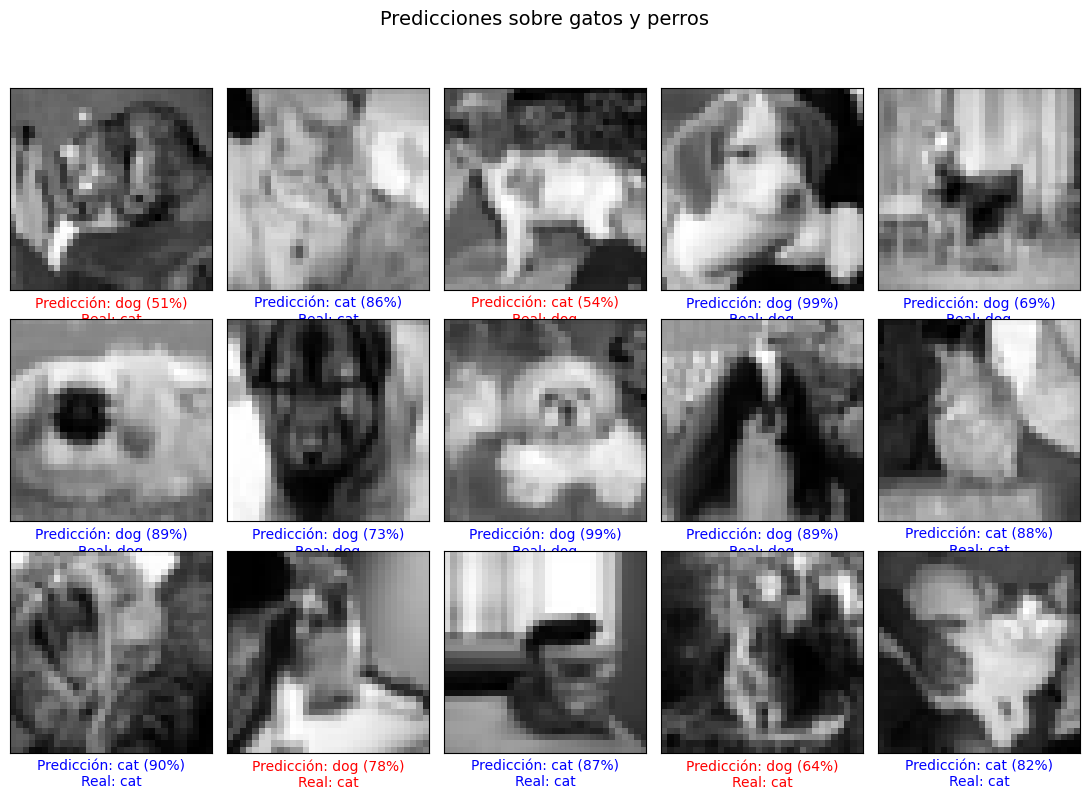

In [15]:
# Predicción sobre un lote de validación y visualización de resultados con indicación de aciertos y errores

for imagenes_animales, etiquetas_animales in lotes_animales_validacion.take(1):  # Toma un único lote del conjunto de validación
    imagenes_animales = imagenes_animales.numpy()                                 # Convierte el tensor de imágenes a array NumPy
    etiquetas_animales = etiquetas_animales.numpy()                               # Convierte el tensor de etiquetas a array NumPy
    probabilidades_animales = modelo_animales.predict(imagenes_animales, verbose=0)  # Genera predicciones para todas las imágenes del lote
    break  # Sale tras el primer lote; solo se necesitan 32 imágenes para la visualización


def graficar_imagen_animal(indice, probabilidades, etiquetas_reales, imagenes):
    probabilidad_clase_uno = probabilidades[indice][0]  # Probabilidad de que la imagen sea un perro (clase 1)
    etiqueta_real = int(etiquetas_reales[indice])       # Clase verdadera: 0=gato, 1=perro
    imagen = imagenes[indice]                           # Array de píxeles de la imagen

    etiqueta_predicha = 1 if probabilidad_clase_uno > 0.5 else 0  # Umbral 0.5: mayor → perro, menor → gato

    color = "blue" if etiqueta_predicha == etiqueta_real else "red"  # Azul si acertó, rojo si falló

    confianza = probabilidad_clase_uno if etiqueta_predicha == 1 else 1 - probabilidad_clase_uno  # Confianza ajustada según la clase predicha

    plt.grid(False)   # Oculta la grilla de fondo
    plt.xticks([])    # Oculta marcas del eje X
    plt.yticks([])    # Oculta marcas del eje Y
    plt.imshow(np.squeeze(imagen), cmap=plt.cm.gray)  # Muestra la imagen en escala de grises eliminando la dimensión de canal
    plt.xlabel(
        f"Predicción: {nombres_clases_animales[etiqueta_predicha]} ({confianza * 100:.0f}%)\n"  # Clase predicha y nivel de confianza
        f"Real: {nombres_clases_animales[etiqueta_real]}",  # Clase verdadera para comparar visualmente
        color=color,  # Azul si acertó, rojo si falló
    )


filas = 3     # Filas de la grilla de visualización
columnas = 5  # Columnas de la grilla de visualización
cantidad_imagenes = filas * columnas  # Total de imágenes a mostrar: 15

plt.figure(figsize=(2 * columnas + 1, 2 * filas + 2))       # Tamaño de figura proporcional a la grilla
plt.suptitle("Predicciones sobre gatos y perros", fontsize=14)  # Título general de la figura

for indice in range(cantidad_imagenes):                           # Itera sobre las 15 imágenes a graficar
    plt.subplot(filas, columnas, indice + 1)                      # Selecciona la celda correspondiente en la grilla
    graficar_imagen_animal(indice, probabilidades_animales, etiquetas_animales, imagenes_animales)  # Dibuja imagen con predicción

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Ajusta márgenes reservando espacio para el título superior
plt.show()                               # Renderiza y muestra la figura completa

**Consigna de lectura:** revisá los errores. ¿Parecen vinculados al animal, al fondo, al encuadre o a la iluminación?
En este set de datos es muy difícil ver las diferencias, están muy pixeladas las imágenes, ya veré qué tal en la versión para google colab

## 16. Métodos para mejorar el rendimiento

Cuando un modelo falla o sobreajusta, podés probar estas estrategias:

- aumentar la variedad del dataset;
- balancear la cantidad de imágenes por clase;
- agregar aumento de datos;
- usar dropout;
- entrenar más épocas solo si la validación también mejora;
- revisar imágenes problemáticas o mal etiquetadas.

## Cierre

En este cuaderno pasaste de imágenes controladas a imágenes reales. Esa transición es importante para entender por qué la calidad del dataset afecta tanto al resultado.

El próximo paso será crear datasets propios, entrenarlos con Teachable Machine y exportar el modelo para usarlo en una interfaz con Gradio.

Un **tensor** es una estructura de datos que guarda números organizados en una o más dimensiones.

Podés pensarlo como una generalización de estos conceptos:

```text
Un número               → tensor de 0 dimensiones
Una lista de números    → tensor de 1 dimensión
Una tabla o matriz      → tensor de 2 dimensiones
Una imagen              → tensor de 3 dimensiones
Un conjunto de imágenes → tensor de 4 dimensiones
```

Por ejemplo:

```text
5
```

es un tensor simple, con un solo valor.

```text
[1, 2, 3, 4]
```

es un tensor de una dimensión.

```text
[
  [1, 2, 3],
  [4, 5, 6]
]
```

es un tensor de dos dimensiones, como una tabla.

En procesamiento de imágenes, una imagen puede representarse como un tensor:

```text
alto x ancho x canales
```

Por ejemplo, una imagen RGB de 100 x 100 píxeles tiene forma:

```text
100 x 100 x 3
```

porque tiene:

- 100 píxeles de alto
- 100 píxeles de ancho
- 3 canales de color: rojo, verde y azul

Un conjunto de 32 imágenes RGB de 100 x 100 tendría forma:

```text
32 x 100 x 100 x 3
```

donde `32` es la cantidad de imágenes del lote.

En TensorFlow, los tensores son el formato principal para trabajar con datos. Las imágenes, etiquetas, pesos del modelo y predicciones suelen representarse como tensores.

En resumen:

```text
Tensor = contenedor de números organizado por dimensiones
```

En redes neuronales, casi todo lo que entra, se procesa y sale del modelo está representado como tensores.